# XAI CODE für Übung 4

## source of this notebook: Explainable AI Specialization on Coursera



# Local Explanations 🏘️

Table of Contents
* LIME 🍋
* SHAP 🎲


First, we will install the necessary libraries. In addition to numpy and pandas, we will use the following libraries:


*   scikit-learn (Model)
*   shap (SHAP)
*   lime (LIME)

In [1]:
!pip install numpy pandas matplotlib scikit-learn lime shap==0.48.0 xgboost==3.0.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 8.2 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dfc90afeb9934faf62921a462c42c6ace166dbd4e654d1e20e98fea4c830bb1e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.1
    Uninstalling xgboost-3.1.1:
      Successfully uninstalled xgboost-3.1.1
  Attempting uninstall: shap
    Found existing installation: shap 0.49.1
    Uninstalling shap-0.49.1:
      Successfully uninstalled shap-0.49.1


In [2]:
# Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Models
import xgboost
from sklearn.model_selection import train_test_split

# XAI
import shap
import lime

np.random.seed(1)

**Dataset**
We will use the classic [UCI adult income dataset](https://archive.ics.uci.edu/dataset/2/adult). This is a classification task to predict if people made over $50k in the 1990's.

**Model**
We will train an XGBoost classifier model with default parameters for explanatory purposes. We are also performing a 50-50 train/test split for optimization purposes.

In [3]:
# Load Data from shap library
X,y = shap.datasets.adult()

The model being trained below may take a few minutes to run.

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Train XGBoost model
model = xgboost.XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

For LIME and Anchors, we need to define some characteristics of our data:

In [5]:
feature_names = ["Age", "Workclass",
                 "Education-Num", "Marital Status", "Occupation",
                 "Relationship", "Race", "Sex", "Capital Gain",
                 "Capital Loss", "Hours per week", "Country"]

categorical_features = ["Workclass", "Marital Status", "Occupation", "Relationship", "Race", "Sex", "Country"]

class_names = ['<=50K', '>50K']

categorical_names = {
    1: ['Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Federal-gov', 'Local-gov', 'State-gov', 'Without-pay', 'Never-worked'],  # Workclass
    3: ['Married-civ-spouse', 'Divorced', 'Never-married', 'Separated', 'Widowed', 'Married-spouse-absent', 'Married-AF-spouse'],  # Marital Status
    4: ['Tech-support', 'Craft-repair', 'Other-service', 'Sales', 'Exec-managerial', 'Prof-specialty', 'Handlers-cleaners', 'Machine-op-inspct', 'Adm-clerical', 'Farming-fishing', 'Transport-moving', 'Priv-house-serv', 'Protective-serv', 'Armed-Forces'],  # Occupation
    5: ['Wife', 'Own-child', 'Husband', 'Not-in-family', 'Other-relative', 'Unmarried'],  # Relationship
    6: ['White', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other', 'Black'],  # Race
    7: ['Female', 'Male'],  # Sex
    11: ['United-States', 'Cambodia', 'England', 'Puerto-Rico', 'Canada', 'Germany', 'Outlying-US(Guam-USVI-etc)', 'India', 'Japan', 'Greece', 'South', 'China', 'Cuba', 'Iran', 'Honduras', 'Philippines', 'Italy', 'Poland', 'Jamaica', 'Vietnam', 'Mexico', 'Portugal', 'Ireland', 'France', 'Dominican-Republic', 'Laos', 'Ecuador', 'Taiwan', 'Haiti', 'Columbia', 'Hungary', 'Guatemala', 'Nicaragua', 'Scotland', 'Thailand', 'Yugoslavia', 'El-Salvador', 'Trinadad&Tobago', 'Peru', 'Hong', 'Holand-Netherlands']  # Country
}

## LIME 🍋

Local interpretable model-agnostic explanations (LIME) [[Paper, 2016]](https://arxiv.org/abs/1602.04938)

Interpretable models that are used to explain individual predictions of black box machine learning model

**LIME Process:**
1.   Select instance of interest
2.   Perturb your dataset and get black box predictions for perturbed samples
3.   Generate a new dataset consisting of perturbed samples (variations of your data) and the corresponding predictions
4.   Train an interpretable model, weighted by the proximity of sampled instances to the instance of interest
5.   Interpret the local model to explain prediction

As opposed to LIME for text, tabular explainers need a training set. This is because statistics are computed on each feature. If the feature is numerical, we compute the mean and std, and discretize it into quartiles. If the feature is categorical, we compute the frequency of each value. This is used to scale the data, so that we can meaningfully compute distances when the attributes are not on the same scale and to sample perturbed instances - which we do by sampling from a Normal(0,1), multiplying by the std and adding back the mean.


LIME uses an exponential smoothing kernel to define the neighborhood.
The kernel width determines how large the neighborhood is:
* Small kernel width = an instance must be very close to influence the local model
* Larger kernel width = instances that are farther away also influence the model

[LIME Code Tutorial from original paper authors](https://marcotcr.github.io/lime/tutorials/Tutorial%20-%20continuous%20and%20categorical%20features.html)

In [14]:
# Define kernel_width
kernel_width = 3

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values ,class_names=class_names, feature_names=feature_names,
                                                   categorical_features=categorical_features,
                                                   categorical_names=categorical_names, kernel_width=kernel_width)

In [17]:
# Choose a sample for explanation
idx = 0

# Explain the prediction using LIME
exp = explainer.explain_instance(X_test.values[idx], model.predict_proba, num_features=12)

print("Label:", y_test[idx])

# Show the explanation
exp.show_in_notebook()

Label: False


### How to Interpret

On the left, the prediction probability is shown. This sample was predicted to be <=50K (this individual in the dataset was predicted to make less than $50k)

For this sample, features that contributed to the prediction of <=50k are shown in blue (left) and features that contributed to a prediction of >50k are shown in orange (right).

The table on the right shows the actual value for each feature for this particular instance and the feature is highlighted with its contribution to each of the binary outcomes.

In [18]:
# Choose a sample for explanation
idx = 100

# Explain the prediction using LIME
exp = explainer.explain_instance(X_test.values[idx], model.predict_proba, num_features=12)

print("Label:", y_test[idx])

# Show the explanation
exp.show_in_notebook()

Label: True


⚠️ Warning about using LIME for tabular data ⚠️

* In tabular data, LIME samples are not taken around the instance of interest, but from the training data’s mass center

* Defining the neighborhood around a point is difficult and can change the results of your local model

* There is not yet a robust way to find the best kernel or width



---



## SHAP 🎲

SHapley Additive exPlanations [Paper, 2017](https://papers.nips.cc/paper_files/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf)


Builds off of Shapley Values by approximating them.

* Shapley Values is a method from coalitional game theory (where game players cooperate in a coalition) that tells us how to fairly distribute “payout” to players depending on their contribution to the total payout [Paper, 1952](https://www.rand.org/content/dam/rand/pubs/papers/2021/P295.pdf)
* For our purposes, we will assume the prediction task is the “game”, each feature value of the instance is a “player”, and the prediction is the “payout”

The `shap` library has great [documentation](https://shap.readthedocs.io/en/latest/) with excellent tutorials.

**The role of the background distribution:**

* *Baseline Value Calculation*: SHAP values explain a prediction by comparing it to a baseline value, which is typically the average prediction over the background dataset. This baseline serves as a reference point to understand how much each feature contributes to the difference between the actual prediction and this average prediction. Below, you will see this variable as `X100`.

* *Expectation of Model Output*: When calculating SHAP values, the background dataset is used to estimate the expected value of the model's output. This expected value is the average prediction across the background dataset and represents what the model would predict in the absence of specific information about a given instance.

* *Marginal Contribution of Features*: SHAP values measure the marginal contribution of each feature to the prediction. This involves considering what the model would predict if each feature were missing or replaced by values from the background distribution. Essentially, SHAP values quantify how much each feature contributes to the difference between the actual prediction and the baseline value derived from the background dataset.

* *Sampling and Computational Efficiency*: Using a background dataset allows SHAP to approximate the impact of removing a feature by averaging over many possible values that the feature could take. This is more computationally efficient than considering all possible combinations of feature values.

...

Below, we implement the **TreeSHAP algorithm**.
You can read more about the TreeSHAP algorithm in the [Interpretable ML Book](https://christophm.github.io/interpretable-ml-book/shap.html#treeshap).

In [8]:
# Compute SHAP values

X100 = shap.utils.sample(X, 100) # 100 instances for use as the background distribution

# Use the TreeExplainer algorithm with background distribution
explainer = shap.TreeExplainer(model, X100)
shap_values = explainer.shap_values(X_test) # Get shap values
shap_values_exp = explainer(X_test) # Get explainer for X_test

100%|===================| 16277/16281 [00:56<00:00]       

/tmp/ipython-input-2853865067.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


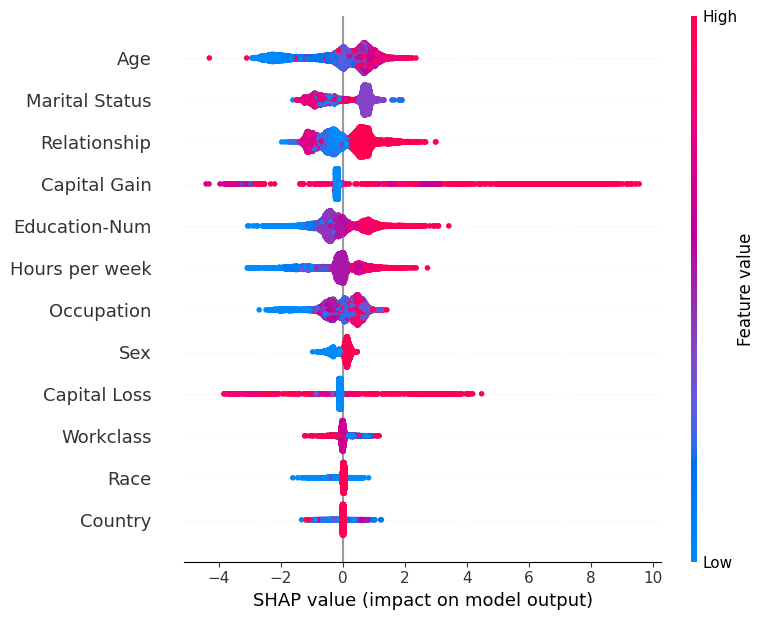

In [9]:
# Visualize SHAP with Summary Plot
shap.summary_plot(shap_values, X_test)

### How to Interpret - SHAP Summary Plot

The Summary Plot is a beeswarm plot. We can see the features listed on the left side of the plot. The bottom shows the SHAP value, which is the impact on the model output.

* For classification models, especially binary classifiers, a negative SHAP value indicates that the feature is contributing to lowering the probability of the positive class, or increasing the probability of the negative class, (<=50k).

* Postive SHAP values indicate that the feature is contributing to increasing the probability of the positive class (>50k)

* Whether the value of the feature is low or high is shown by the color, with low feature values in blue and high feature values shown in red. This is normalized by feature.

/tmp/ipython-input-3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


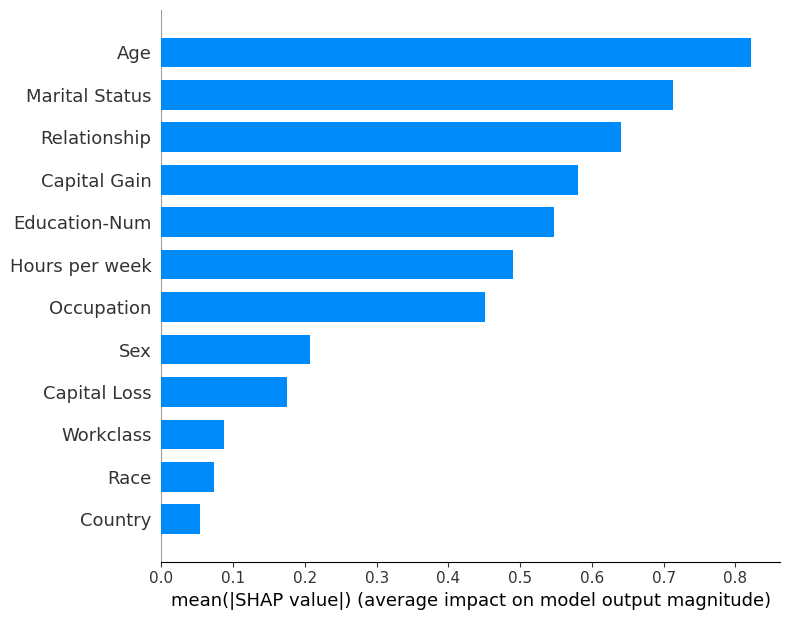

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

### How to Interpret - SHAP Bar chart

This plot takes the average of the SHAP value magnitudes across the dataset and plots it as a simple bar chart.

We can visualize the largest contributors more globally with this plot.

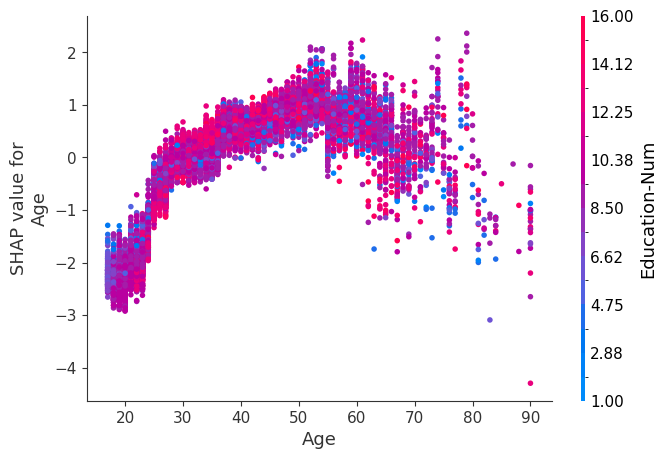

In [11]:
# Visualize SHAP with Dependence Plot
shap.dependence_plot('Age', shap_values, X_test)

### How to Interpret - SHAP Dependence Plot

SHAP dependence plots show the effect of a single feature across the whole dataset. They plot a feature’s value vs. the SHAP value of that feature across many samples. SHAP dependence plots may look similar to partial dependence plots, but account for the interaction effects present in the features, and are only defined in regions of the input space supported by data. The vertical dispersion of SHAP values at a single feature value is driven by interaction effects, and another feature is chosen for coloring to highlight possible interactions.
[Source](https://shap-lrjball.readthedocs.io/en/latest/example_notebooks/tree_explainer/Census%20income%20classification%20with%20XGBoost.html#SHAP-Dependence-Plots)

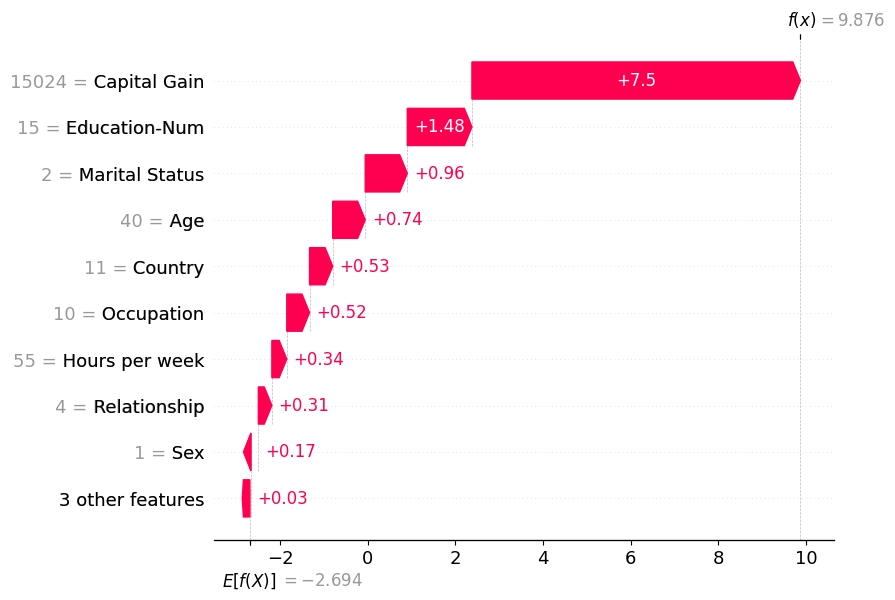

In [12]:
# Visualize an instance with a waterfall plot of the SHAP values

# Choose a sample for explanation
idx = 100

# Plot waterfall plot
shap.plots.waterfall(shap_values_exp[idx])

#### How to Interpret - SHAP Waterfall Plot

You can visualize the SHAP values for an instance of interest. For an instance of interest, you can see the SHAP values and their contribution to the prediction for that instance.

On the left side of the feature names are the specific feature values for the instance of interest


---



**Local interpretability: How do we interpret the SHAP force plot?**

The Shapley values can be understood as forces that push the output of the model. Forces of Shapley values in blue represent the features that decrease the probability of default, while red values represent the features that are incrementing the probability of positive class (>50k).

A force plot allows us to study a concrete case.



In [13]:
shap.initjs()
idx = 100
shap.force_plot(explainer.expected_value, shap_values[idx, :], X_test.iloc[idx,:])